In [6]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from scipy.cluster.hierarchy import dendrogram, linkage, cophenet
from scipy.spatial.distance import pdist
from sklearn.cluster import AgglomerativeClustering
from sklearn.metrics import silhouette_score
from sklearn.metrics import davies_bouldin_score

# Data Collecting

In [7]:
data = pd.read_excel("D:/Semester 1-7/Semester 5/BPBD/Data Kejadian 23-24.xlsx")

C:\Users\Hp\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.13_qbz5n2kfra8p0\LocalCache\local-packages\Python313\site-packages\openpyxl\worksheet\_reader.py:329: UserWarning: Data Validation extension is not supported and will be removed
  warn(msg)


In [8]:
sheet_name = 'DATA KEJADIAN'
data_kejadian = pd.read_excel('D:/Semester 1-7/Semester 5/BPBD/Data Kejadian 23-24.xlsx', sheet_name=sheet_name)
data_kejadian.head()

,Unnamed: 0,NO,NO.1,TANGGAL,JENIS KEJADIAN,JENIS LAKA,KECAMATAN,KELURAHAN,WILAYAH,LOKASI,...,TINDAK LANJUT DM,PUSKESMAS,TIMPAHAN P. TUMBANG,JENIS POHON,PENYEBAB ROBOH,YANG TERBAKAR,JENIS PSIKOSOSIAL,JENIS HEWAN,JAM KE-,RUAS JALAN
0,January 2023,NaN,1.0,2023-01-01,Kecelakaan,Tunggal,Tegalsari,Dr. Soetomo,Surabaya Pusat,Jln. Diponegoro No.121,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,JAM KE-2,Jl. Diponegoro
1,January 2023,NaN,2.0,2023-01-01,Kecelakaan,Tunggal,Wonokromo,Ngagel Rejo,Surabaya Selatan,Jln. Bratang Gede No.112,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,JAM KE-3,NaN
2,January 2023,NaN,3.0,2023-01-01,Kecelakaan,R2 Vs R4,Genteng,Embong Kaliasin,Surabaya Pusat,Depan BAPEM Jl. Gubernur Suryo No.15,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,JAM KE-3,NaN
3,January 2023,NaN,4.0,2023-01-01,Darurat Medis,NaN,Jambangan,Kebonsari,Surabaya Selatan,Jln. Kebonsari VI No.12 C,...,Rujukan,NaN,NaN,NaN,NaN,NaN,NaN,NaN,JAM KE-3,NaN
4,January 2023,NaN,5.0,2023-01-01,Darurat Medis,NaN,Dukuh Pakis,Pradah Kalikendal,Surabaya Selatan,Jln. Pradah Indah III No.05,...,Kematian,NaN,NaN,NaN,NaN,NaN,NaN,NaN,JAM KE-3,NaN


# Data Preprocessing

In [9]:
kejadian_count = data_kejadian['JENIS KEJADIAN'].value_counts()
kejadian_count

JENIS KEJADIAN
Darurat Medis               12519
Kecelakaan                  11827
Kebakaran                    1776
Pohon Tumbang                 442
Penemuan Jenazah              425
Genangan                      226
Masalah Hewan                 218
Rumah Roboh                   206
Orang Tersesat                 94
Psikososial                    89
Orang Meninggal Mendadak       77
Lainnya Darurat                47
Orang Tenggelam                22
Name: count, dtype: int64

In [10]:
variabel_kejadian = data_kejadian[data_kejadian['JENIS KEJADIAN'].isin(['Darurat Medis', 'Genangan', 'Kebakaran', 'Kecelakaan', 'Rumah Roboh', 'Pohon Tumbang'])]

In [11]:
#Jumlah Variabel Baru di Jenis Kejadian

count_kejadian_tertentu = variabel_kejadian['JENIS KEJADIAN'].value_counts()
count_kejadian_tertentu

JENIS KEJADIAN
Darurat Medis    12519
Kecelakaan       11827
Kebakaran         1776
Pohon Tumbang      442
Genangan           226
Rumah Roboh        206
Name: count, dtype: int64

In [12]:
# Mengecek missing values pada kolom KELURAHAN, TANGGAL, JENIS KEJADIAN
print(data_kejadian[['KELURAHAN', 'TANGGAL', 'JENIS KEJADIAN']].isnull().sum())

# Mengonversi kolom KORBAN TERDAMPAK, KORBAN LUKA, dan KORBAN MENINGGAL ke tipe numerik dan mengisi missing values
data_kejadian[['KORBAN TERDAMPAK', 'KORBAN LUKA']] = data_kejadian[['KORBAN TERDAMPAK', 'KORBAN LUKA']].apply(pd.to_numeric, errors='coerce').fillna(0)
data_kejadian['KORBAN MENINGGAL'] = pd.to_numeric(data_kejadian['KORBAN MENINGGAL'], errors='coerce')

# Menghapus baris dengan missing values pada kolom KORBAN MENINGGAL
data_kejadian.dropna(subset=['KORBAN MENINGGAL'], inplace=True)

# Mengecek apakah masih ada missing values setelah proses
print(data_kejadian[['KORBAN TERDAMPAK', 'KORBAN LUKA', 'KORBAN MENINGGAL']].isnull().sum())

# Mengonversi kolom 'JENIS KEJADIAN' ke tipe string dan memastikan tidak ada NaN
data_kejadian['JENIS KEJADIAN'] = data_kejadian['JENIS KEJADIAN'].astype(str)

# Mengecek nilai unik pada kolom KORBAN TERDAMPAK, KORBAN LUKA, dan KORBAN MENINGGAL secara terpisah
print(data_kejadian['KORBAN TERDAMPAK'].unique())
print(data_kejadian['KORBAN LUKA'].unique())
print(data_kejadian['KORBAN MENINGGAL'].unique())

# Mengecek apakah masih ada NaN pada kolom 'JENIS KEJADIAN'
print(data_kejadian['JENIS KEJADIAN'].isna().sum())  # Pastikan tidak ada NaN

KELURAHAN         98
TANGGAL           98
JENIS KEJADIAN    98
dtype: int64
KORBAN TERDAMPAK    0
KORBAN LUKA         0
KORBAN MENINGGAL    0
dtype: int64
[ 1.  2.  0.  3.  4.  5.  9.  6. 10. 13. 11. 24. 12.  7. 14.  8. 25. 16.
 34. 15. 18. 35. 90. 48. 21. 20. 19. 36.]
[ 1.  2.  0.  3.  4.  5. 10.  6.  7. 12. 11.  8. 16. 14.  9.]
[0. 1. 2. 3. 9.]
0


In [13]:
# Daftar jenis kejadian yang ingin difilter
jenis_kejaian_filter = ['Darurat Medis', 'Genangan', 'Kebakaran', 'Kecelakaan', 'Rumah Roboh', 'Pohon Tumbang']

# Mengubah kolom TANGGAL menjadi format datetime
data_kejadian['TANGGAL'] = pd.to_datetime(data_kejadian['TANGGAL'], errors='coerce')

# Menambahkan kolom 'Bulan' untuk mempermudah filter
data_kejadian['Bulan'] = data_kejadian['TANGGAL'].dt.month

# Memfilter data berdasarkan bulan (April sampai Oktober) dan jenis kejadian
data_kejadian_filtered = data_kejadian[
    (data_kejadian['Bulan'] >= 4) & (data_kejadian['Bulan'] <= 10) & 
    (data_kejadian['JENIS KEJADIAN'].isin(jenis_kejaian_filter))
]

# Normalisasi nama kelurahan
data_kejadian_filtered['KELURAHAN'] = data_kejadian_filtered['KELURAHAN'].str.strip().str.title()

# Menghitung jumlah kejadian per KELURAHAN dan JENIS KEJADIAN
pivot_table = data_kejadian_filtered.pivot_table(
    index='KELURAHAN', 
    columns='JENIS KEJADIAN', 
    aggfunc='size', 
    fill_value=0
)

# Memfilter jumlah korban berdasarkan jenis kejadian yang diinginkan
pivot_table['Korban Terdampak'] = data_kejadian_filtered.groupby('KELURAHAN')['KORBAN TERDAMPAK'].sum().reindex(pivot_table.index, fill_value=0)
pivot_table['Korban Luka'] = data_kejadian_filtered.groupby('KELURAHAN')['KORBAN LUKA'].sum().reindex(pivot_table.index, fill_value=0)
pivot_table['Korban Meninggal'] = data_kejadian_filtered.groupby('KELURAHAN')['KORBAN MENINGGAL'].sum().reindex(pivot_table.index, fill_value=0)

# Mengubah penulisan huruf pertama pada indeks (KELURAHAN) dan kolom (JENIS KEJADIAN, KORBAN TERDAMPAK, dsb) menjadi kapital
pivot_table.index = pivot_table.index.str.title()  # Mengubah KELURAHAN menjadi format kapital pada setiap kata
pivot_table.columns = pivot_table.columns.str.title()  # Mengubah nama kolom menjadi format kapital

# Reset index untuk tampilan yang lebih bersih
pivot_table.reset_index(inplace=True)

# Menampilkan hasil
pivot_table

C:\Users\Hp\AppData\Local\Temp\ipykernel_5500\4197309897.py:17: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  data_kejadian_filtered['KELURAHAN'] = data_kejadian_filtered['KELURAHAN'].str.strip().str.title()


JENIS KEJADIAN,KELURAHAN,Darurat Medis,Genangan,Kebakaran,Kecelakaan,Pohon Tumbang,Rumah Roboh,Korban Terdampak,Korban Luka,Korban Meninggal
0,Airlangga,93,1,5,106,2,0,290.0,244.0,17.0
1,Alun-Alun Contong,37,0,8,77,0,1,180.0,157.0,6.0
2,Ampel,26,0,2,4,0,0,34.0,26.0,7.0
3,Asem Rowo,70,0,35,99,0,2,239.0,182.0,20.0
4,Babat Jerawat,52,0,19,19,0,3,117.0,64.0,11.0
...,...,...,...,...,...,...,...,...,...,...
148,Wiyung,21,2,14,21,0,1,63.0,52.0,3.0
149,Wonokromo,104,0,7,99,1,0,266.0,235.0,18.0
150,Wonokusumo,71,0,12,1,0,2,102.0,64.0,11.0
151,Wonorejo Rungkut,33,0,17,9,0,0,46.0,38.0,4.0


# Normalize

In [14]:
from sklearn.preprocessing import normalize

data_scaled = normalize(pivot_table.drop(columns='KELURAHAN'))  # Drop 'KELURAHAN' for normalization
data_scaled = pd.DataFrame(data_scaled, columns=pivot_table.columns[1:])  # Create DataFrame without 'KELURAHAN'
data_scaled.head()

JENIS KEJADIAN,Darurat Medis,Genangan,Kebakaran,Kecelakaan,Pohon Tumbang,Rumah Roboh,Korban Terdampak,Korban Luka,Korban Meninggal
0,0.229759,0.002471,0.012353,0.261876,0.004941,0.000000,0.716454,0.602809,0.041999
1,0.145746,0.000000,0.031513,0.303309,0.000000,0.003939,0.709035,0.618436,0.023635
2,0.512172,0.000000,0.039398,0.078796,0.000000,0.000000,0.669764,0.512172,0.137893
3,0.214423,0.000000,0.107211,0.303255,0.000000,0.006126,0.732100,0.557499,0.061264
4,0.355956,0.000000,0.130061,0.130061,0.000000,0.020536,0.800900,0.438099,0.075298


In [15]:
from scipy.cluster.hierarchy import linkage, dendrogram, cophenet
from scipy.spatial.distance import pdist

single_clustering = linkage(data_scaled, method="single", metric="euclidean")
coph_single, coph_dists_single = cophenet(single_clustering, pdist(data_scaled))

complete_clustering = linkage(data_scaled, method="complete", metric="euclidean")
coph_complete, coph_dists_complete = cophenet(complete_clustering, pdist(data_scaled))

average_clustering = linkage(data_scaled, method="average", metric="euclidean")
coph_average, coph_dists_average = cophenet(average_clustering, pdist(data_scaled))

ward_clustering = linkage(data_scaled, method="ward", metric="euclidean")
coph_ward, coph_dists_ward = cophenet(ward_clustering, pdist(data_scaled))

print(F'Korelasi Cophenetic (Single Linkage): {coph_single:.4f}')
print(F'Korelasi Cophenetic (Complete Linkage): {coph_complete:.4f}')
print(F'Korelasi Cophenetic (Average Linkage): {coph_average:.4f}')
print(F'Korelasi Cophenetic (Ward Linkage): {coph_ward:.4f}')

Korelasi Cophenetic (Single Linkage): 0.8154
Korelasi Cophenetic (Complete Linkage): 0.6625
Korelasi Cophenetic (Average Linkage): 0.9105
Korelasi Cophenetic (Ward Linkage): 0.5431


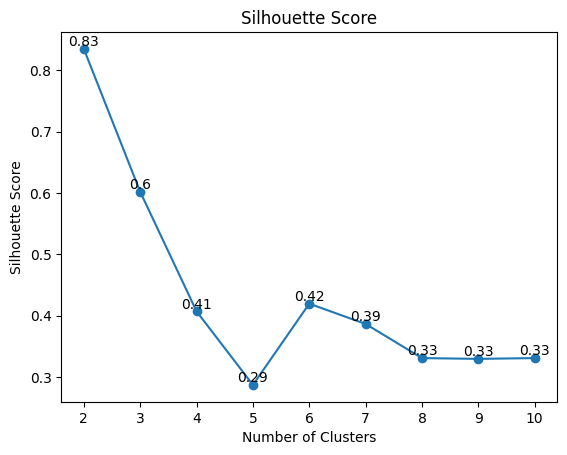

In [16]:
from sklearn.cluster import AgglomerativeClustering
from sklearn.metrics import silhouette_score

silhouette_scores = []
for n_cluster in range(2, 11):
    clusterer = AgglomerativeClustering(n_clusters=n_cluster, linkage='average')
    cluster_labels = clusterer.fit_predict(data_scaled)
    silhouette_avg = silhouette_score(data_scaled, cluster_labels)
    silhouette_scores.append(silhouette_avg)

# Plotting Elbow Method
plt.plot(range(2, 11), silhouette_scores, marker='o')
for i, score in enumerate(silhouette_scores):
    plt.text(i + 2, score, round(score, 2), ha='center', va='bottom') 
plt.xlabel('Number of Clusters')
plt.ylabel('Silhouette Score')
plt.title('Silhouette Score')
plt.show()

In [17]:
from sklearn.cluster import AgglomerativeClustering

# Data kelurahan
kelurahan = pivot_table['KELURAHAN']

# Menggunakan Single Linkage
agglo = AgglomerativeClustering(n_clusters=3, linkage='average').fit(data_scaled)

# Membuat DataFrame hasil clustering
hasil_agglo = pd.DataFrame(data_scaled, columns=data_scaled.columns)
hasil_agglo['Cluster'] = agglo.labels_  # Menambahkan label kluster
hasil_agglo['Kelurahan'] = kelurahan.reset_index(drop=True)  # Menambahkan data kelurahan

# Kelurahan per cluster
kelurahan_per_cluster = hasil_agglo[['Cluster', 'Kelurahan']].reset_index(drop=True)

kelurahan_per_cluster

JENIS KEJADIAN,Cluster,Kelurahan
0,0,Airlangga
1,0,Alun-Alun Contong
2,0,Ampel
3,0,Asem Rowo
4,0,Babat Jerawat
...,...,...
148,0,Wiyung
149,0,Wonokromo
150,0,Wonokusumo
151,0,Wonorejo Rungkut


In [19]:
# Menampilkan jumlah anggota di setiap cluster
cluster_counts = kelurahan_per_cluster['Cluster'].value_counts().sort_index()
print(cluster_counts)


Cluster
0    150
1      1
2      2
Name: count, dtype: int64


# StandarScaler

In [20]:
# Normalisasi data menggunakan StandardScaler

from sklearn.preprocessing import StandardScaler
X = pivot_table.drop(columns='KELURAHAN')
data_normalized = pd.DataFrame(StandardScaler().fit_transform(X), columns=X.columns)
data_normalized

JENIS KEJADIAN,Darurat Medis,Genangan,Kebakaran,Kecelakaan,Pohon Tumbang,Rumah Roboh,Korban Terdampak,Korban Luka,Korban Meninggal
0,1.025435,0.511039,-0.550133,0.957907,0.993128,-0.530213,1.112898,1.087824,1.554474
1,-0.395316,-0.466323,-0.093513,0.456937,-0.676637,0.737327,0.234912,0.290027,-0.256031
2,-0.674393,-0.466323,-1.006753,-0.804127,-0.676637,-0.530213,-0.930415,-0.911255,-0.091440
3,0.441912,-0.466323,4.016071,0.836983,-0.676637,2.004867,0.705832,0.519279,2.048247
4,-0.014758,-0.466323,1.580762,-0.545004,-0.676637,3.272407,-0.267934,-0.562792,0.566926
...,...,...,...,...,...,...,...,...,...
148,-0.801245,1.488400,0.819728,-0.510455,-0.676637,0.737327,-0.698946,-0.672833,-0.749805
149,1.304511,-0.466323,-0.245719,0.836983,0.158246,-0.530213,0.921337,1.005293,1.719065
150,0.467283,-0.466323,0.515314,-0.855952,-0.676637,2.004867,-0.387660,-0.562792,0.566926
151,-0.496799,-0.466323,1.276348,-0.717753,-0.676637,-0.530213,-0.834634,-0.801214,-0.585214


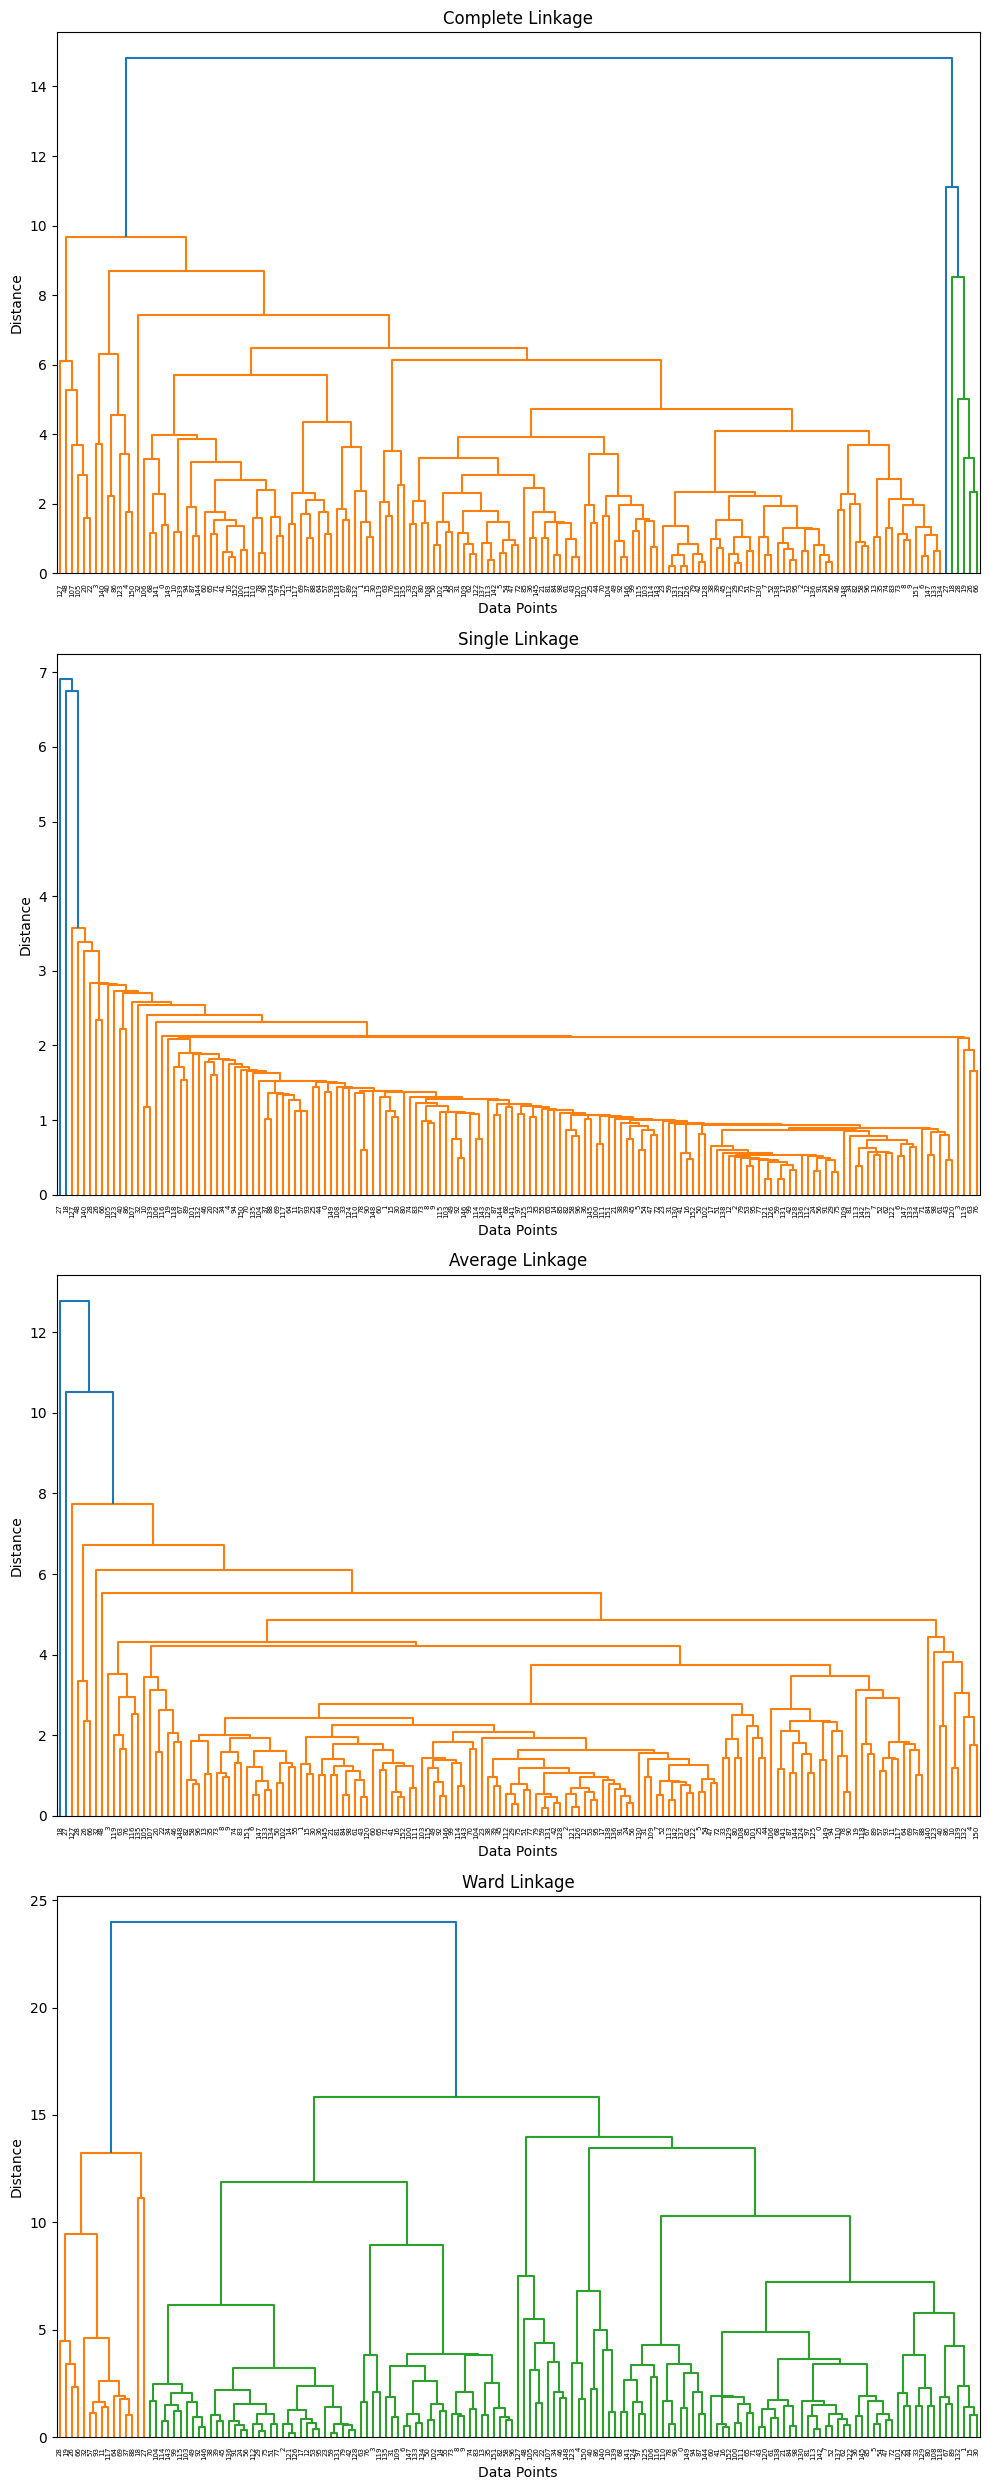

In [21]:
# Plot dendrogram untuk beberapa metode linkage
fig, axs = plt.subplots(4, 1, figsize=(10, 25))

methods = ["complete", "single", "average", "ward"]
linkages = []

for i, method in enumerate(methods):
    linkages.append(linkage(data_normalized, method=method, metric="euclidean"))
    dendrogram(linkages[i], ax=axs[i])
    axs[i].set_title(f'{method.capitalize()} Linkage')
    axs[i].set_xlabel('Data Points')
    axs[i].set_ylabel('Distance')

plt.tight_layout()
plt.show()

In [22]:

# Metode Single Linkage
single_clustering = linkage(data_normalized, method="single", metric="euclidean")
coph_single, coph_dists_single = cophenet(single_clustering, pdist(data_normalized))

# Metode Complete Linkage
complete_clustering = linkage(data_normalized, method="complete", metric="euclidean")
coph_complete, coph_dists_complete = cophenet(complete_clustering, pdist(data_normalized))

# Metode Average Linkage
average_clustering = linkage(data_normalized, method="average", metric="euclidean")
coph_average, coph_dists_average = cophenet(average_clustering, pdist(data_normalized))

# Metode Ward Linkage
ward_clustering = linkage(data_normalized, method="ward", metric="euclidean")
coph_ward, coph_dists_ward = cophenet(ward_clustering, pdist(data_normalized))

print(F'Korelasi Cophenetic (Single Linkage): {coph_single:.4f}')
print(F'Korelasi Cophenetic (Complete Linkage): {coph_complete:.4f}')
print(F'Korelasi Cophenetic (Average Linkage): {coph_average:.4f}')
print(F'Korelasi Cophenetic (Ward Linkage): {coph_ward:.4f}')

Korelasi Cophenetic (Single Linkage): 0.8875
Korelasi Cophenetic (Complete Linkage): 0.8096
Korelasi Cophenetic (Average Linkage): 0.9007
Korelasi Cophenetic (Ward Linkage): 0.5441


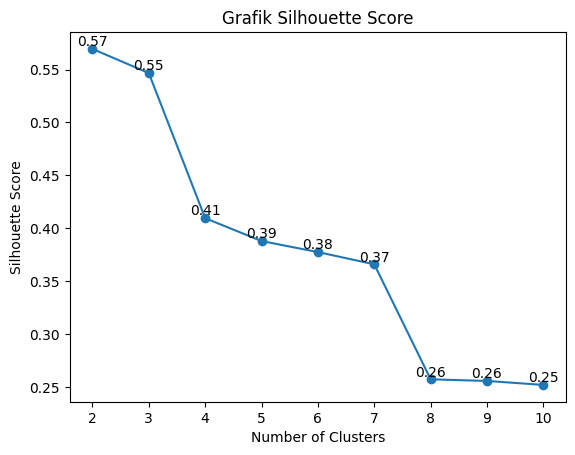

In [23]:
from sklearn.cluster import AgglomerativeClustering
from sklearn.metrics import silhouette_score
import matplotlib.pyplot as plt

silhouette_scores = []
for n_cluster in range(2, 11):
    # Menggunakan Complete Linkage
    clusterer = AgglomerativeClustering(n_clusters=n_cluster, linkage='complete')
    cluster_labels = clusterer.fit_predict(data_normalized)
    silhouette_avg = silhouette_score(data_normalized, cluster_labels)
    silhouette_scores.append(silhouette_avg)

# Plotting Elbow Method
plt.plot(range(2, 11), silhouette_scores, marker='o')
for i, score in enumerate(silhouette_scores):
    plt.text(i + 2, score, round(score, 2), ha='center', va='bottom')  
plt.xlabel('Number of Clusters')
plt.ylabel('Silhouette Score')
plt.title('Grafik Silhouette Score')
plt.show()

# N CLuster

In [24]:
# Data kelurahan
kelurahan = pivot_table['KELURAHAN']

# Menggunakan Single Linkage
agglo = AgglomerativeClustering(n_clusters=4, linkage='complete').fit(data_normalized)

# Membuat DataFrame hasil clustering
hasil_agglo = pd.DataFrame(data_normalized, columns=data_normalized.columns)
hasil_agglo['Cluster'] = agglo.labels_  # Menambahkan label kluster
hasil_agglo['Kelurahan'] = kelurahan.reset_index(drop=True)  # Menambahkan data kelurahan

hasil_agglo['KORBAN TERDAMPAK'] = data_kejadian['KORBAN TERDAMPAK'].reset_index(drop=True)
hasil_agglo['KORBAN LUKA'] = data_kejadian['KORBAN LUKA'].reset_index(drop=True)
hasil_agglo['KORBAN MENINGGAL'] = data_kejadian['KORBAN MENINGGAL'].reset_index(drop=True)

# Kelurahan per cluster
kelurahan_per_cluster = hasil_agglo[['Cluster', 'Kelurahan']].reset_index(drop=True)

kelurahan_per_cluster

JENIS KEJADIAN,Cluster,Kelurahan
0,0,Airlangga
1,0,Alun-Alun Contong
2,0,Ampel
3,0,Asem Rowo
4,0,Babat Jerawat
...,...,...
148,0,Wiyung
149,0,Wonokromo
150,0,Wonokusumo
151,0,Wonorejo Rungkut


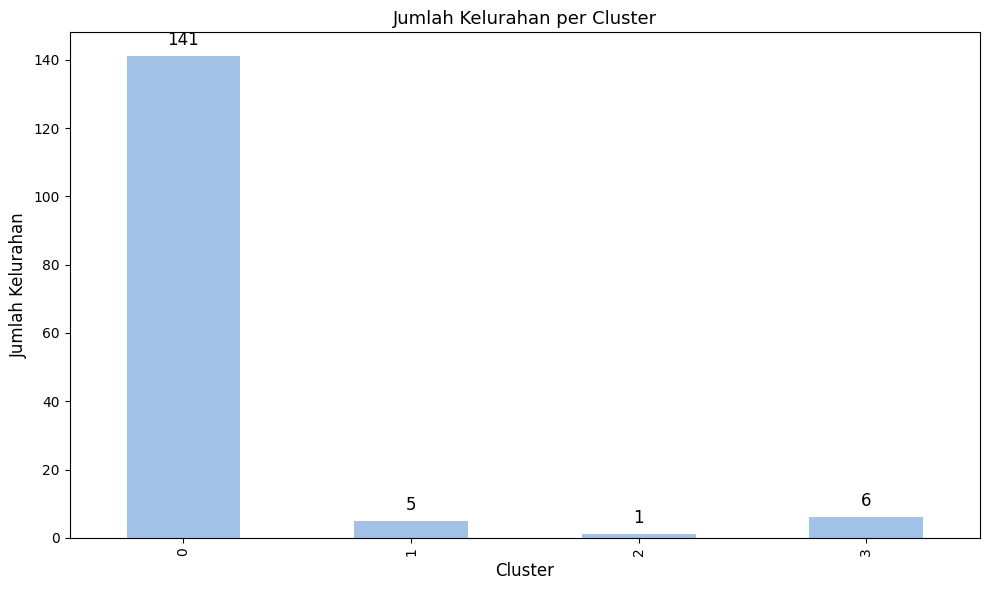

In [25]:
# Menghitung jumlah kelurahan per cluster
kelurahan_per_cluster_count = kelurahan_per_cluster.groupby('Cluster')['Kelurahan'].nunique()

# Membuat bar plot
plt.figure(figsize=(10, 6))
bars = kelurahan_per_cluster_count.plot(kind='bar', color='#A2C2E7')

# Menambahkan nilai pada setiap batang
for bar in bars.patches:
    height = bar.get_height() 
    bars.annotate(f'{height}', 
                 xy=(bar.get_x() + bar.get_width() / 2, height), 
                 xytext=(0, 5),  
                 textcoords="offset points",
                 ha='center', va='bottom', fontsize=12, color='black')

# Menambahkan judul dan label
plt.title('Jumlah Kelurahan per Cluster', fontsize=13)
plt.xlabel('Cluster', fontsize=12)
plt.ylabel('Jumlah Kelurahan', fontsize=12)

# Menampilkan plot
plt.tight_layout()
plt.show()

In [26]:
# Menampilkan isi dari masing-masing cluster
for i in range(4):  # Karena kita punya 4 cluster
    print(f"Cluster {i}:")
    cluster_isi = kelurahan_per_cluster[kelurahan_per_cluster['Cluster'] == i]
    print(cluster_isi['Kelurahan'].tolist())  # Menampilkan list Kelurahan di cluster i
    print("\n")

Cluster 0:
['Airlangga', 'Alun-Alun Contong', 'Ampel', 'Asem Rowo', 'Babat Jerawat', 'Babatan', 'Balas Klumprik', 'Balongsari', 'Bangkingan', 'Banjar Sugihan', 'Banyu Urip', 'Baratajaya', 'Bendul Merisi', 'Benowo', 'Bongkaran', 'Bubutan', 'Bulak', 'Bulak Banteng', 'Dukuh Menanggal', 'Dukuh Setro', 'Dukuh Sutorejo', 'Dupak', 'Gebang Putih', 'Genteng', 'Genting Kalianak', 'Gubeng', 'Gundih', 'Gunung Anyar', 'Gunung Anyar Tambak', 'Gunung Sari', 'Jagir', 'Jajar Tunggal', 'Jambangan', 'Jemur Wonosari', 'Jepara', 'Jeruk', 'Kalijudan', 'Kalirungkut', 'Kalisari', 'Kandangan', 'Kapasan', 'Kapasmadya Baru', 'Karah', 'Karang Pilang', 'Karang Poh', 'Kebonsari', 'Kebraon', 'Kedung Baruk', 'Kedung Cowek', 'Kedungdoro', 'Kedurus', 'Kejawan Putih Tambak', 'Kemayoran', 'Kendangsari', 'Kenjeran', 'Keputih', 'Keputran', 'Kertajaya', 'Ketintang', 'Klampis Ngasem', 'Krembangan Selatan', 'Krembangan Utara', 'Kupang Krajan', 'Kutisari', 'Lakarsantri', 'Lidah Kulon', 'Lidah Wetan', 'Lontar', 'Made', 'Manukan

# Cluster 1

In [27]:
# Menampilkan anggota Cluster 1
cluster_1 = hasil_agglo[hasil_agglo['Cluster'] == 0]

# Memilih kolom yang diinginkan
cluster_1_selected = cluster_1[['Darurat Medis', 'Genangan', 'Kebakaran', 'Kecelakaan', 'Pohon Tumbang', 'Rumah Roboh', 'Kelurahan', 'Cluster']]

# Menampilkan hasil
cluster_1_selected

JENIS KEJADIAN,Darurat Medis,Genangan,Kebakaran,Kecelakaan,Pohon Tumbang,Rumah Roboh,Kelurahan,Cluster
0,1.025435,0.511039,-0.550133,0.957907,0.993128,-0.530213,Airlangga,0
1,-0.395316,-0.466323,-0.093513,0.456937,-0.676637,0.737327,Alun-Alun Contong,0
2,-0.674393,-0.466323,-1.006753,-0.804127,-0.676637,-0.530213,Ampel,0
3,0.441912,-0.466323,4.016071,0.836983,-0.676637,2.004867,Asem Rowo,0
4,-0.014758,-0.466323,1.580762,-0.545004,-0.676637,3.272407,Babat Jerawat,0
...,...,...,...,...,...,...,...,...
148,-0.801245,1.488400,0.819728,-0.510455,-0.676637,0.737327,Wiyung,0
149,1.304511,-0.466323,-0.245719,0.836983,0.158246,-0.530213,Wonokromo,0
150,0.467283,-0.466323,0.515314,-0.855952,-0.676637,2.004867,Wonokusumo,0
151,-0.496799,-0.466323,1.276348,-0.717753,-0.676637,-0.530213,Wonorejo Rungkut,0


In [28]:
# Menyaring hanya kolom numerik yang relevan untuk perhitungan rata-rata
kolom_relevan = ['Darurat Medis', 'Genangan', 'Kebakaran', 'Kecelakaan', 'Pohon Tumbang', 'Rumah Roboh']

# Menghitung rata-rata hanya pada kolom relevan untuk setiap cluster
mean_cluster_1 = hasil_agglo[hasil_agglo['Cluster'] == 0][kolom_relevan].mean(numeric_only=True)
mean_cluster_2 = hasil_agglo[hasil_agglo['Cluster'] == 1][kolom_relevan].mean(numeric_only=True)
mean_cluster_3 = hasil_agglo[hasil_agglo['Cluster'] == 2][kolom_relevan].mean(numeric_only=True)
mean_cluster_4 = hasil_agglo[hasil_agglo['Cluster'] == 3][kolom_relevan].mean(numeric_only=True)

# Membuat dictionary untuk rata-rata setiap cluster
mean_dict = {
    'Cluster 1': mean_cluster_1,
    'Cluster 2': mean_cluster_2,
    'Cluster 3': mean_cluster_3,
    'Cluster 4': mean_cluster_4
}

# Membuat DataFrame dari dictionary
mean_df = pd.DataFrame(mean_dict).T  
mean_df.columns.name = 'Metrics'  
mean_df.reset_index(inplace=True)

# Menampilkan DataFrame yang sudah diperbaiki
mean_df


Metrics,index,Darurat Medis,Genangan,Kebakaran,Kecelakaan,Pohon Tumbang,Rumah Roboh
0,Cluster 1,-0.091230,-0.182125,-0.024426,-0.154421,-0.048995,-0.008813
1,Cluster 2,0.370874,0.511039,-0.123954,4.032829,1.661034,0.230311
2,Cluster 3,5.998064,-0.466323,1.732969,1.389778,0.993128,-0.530213
3,Cluster 4,0.835156,3.931804,0.388475,0.036582,-0.398343,0.103557


Cluster 2

In [29]:
# Menampilkan anggota Cluster 2
cluster_2 = hasil_agglo[hasil_agglo['Cluster'] == 1]

# Memilih kolom yang diinginkan
cluster_2_selected = cluster_2[['Darurat Medis', 'Genangan', 'Kebakaran', 'Kecelakaan', 'Pohon Tumbang', 'Rumah Roboh', 'Kelurahan', 'Cluster']]

# Menampilkan hasil
cluster_2_selected

JENIS KEJADIAN,Darurat Medis,Genangan,Kebakaran,Kecelakaan,Pohon Tumbang,Rumah Roboh,Kelurahan,Cluster
18,0.213577,0.511039,0.971935,7.125026,5.167539,0.737327,Darmo,1
19,0.289689,-0.466323,-0.245719,2.581742,2.662892,0.737327,Dr. Soetomo,1
26,0.720988,-0.466323,-0.550133,3.825531,0.993128,0.737327,Embong Kaliasin,1
28,-0.496799,2.465762,-0.397926,3.721882,-0.676637,-0.530213,Gayungan,1
66,1.126917,0.511039,-0.397926,2.909964,0.158246,-0.530213,Ketabang,1


Cluster 3

In [30]:
# Menampilkan anggota Cluster 3
cluster_3 = hasil_agglo[hasil_agglo['Cluster'] == 2]

# Memilih kolom yang diinginkan
cluster_3_selected = cluster_3[['Darurat Medis', 'Genangan', 'Kebakaran', 'Kecelakaan', 'Pohon Tumbang', 'Rumah Roboh', 'Kelurahan', 'Cluster']]

# Menampilkan hasil
cluster_3_selected

JENIS KEJADIAN,Darurat Medis,Genangan,Kebakaran,Kecelakaan,Pohon Tumbang,Rumah Roboh,Kelurahan,Cluster
27,5.998064,-0.466323,1.732969,1.389778,0.993128,-0.530213,Gading,2


CLuster 4

In [31]:
# Menampilkan anggota Cluster 4
cluster_4 = hasil_agglo[hasil_agglo['Cluster'] == 3]

# Memilih kolom yang diinginkan
cluster_4_selected = cluster_4[['Darurat Medis', 'Genangan', 'Kebakaran', 'Kecelakaan', 'Pohon Tumbang', 'Rumah Roboh', 'Kelurahan', 'Cluster']]

# Menampilkan hasil
cluster_4_selected

JENIS KEJADIAN,Darurat Medis,Genangan,Kebakaran,Kecelakaan,Pohon Tumbang,Rumah Roboh,Kelurahan,Cluster
20,-0.243093,3.443123,-0.550133,-0.372256,0.158246,-0.530213,Dukuh Kupang,3
22,-0.446058,3.443123,0.058694,0.491486,-0.676637,-0.530213,Dukuh Pakis,3
48,0.365800,3.443123,-0.702340,0.197814,-0.676637,3.272407,Kapasari,3
105,1.608958,4.420485,0.667521,-0.683203,-0.676637,-0.530213,Petemon,3
107,-0.243093,3.443123,2.798416,0.560586,-0.676637,-0.530213,Pradah Kalikendal,3
127,3.968419,5.397846,0.058694,0.025065,0.158246,-0.530213,Simomulyo,3


# Rata - Rata Tiap Cluster

In [32]:
mean_cluster_1 = hasil_agglo[hasil_agglo['Cluster'] == 0].mean(numeric_only=True)
mean_cluster_2 = hasil_agglo[hasil_agglo['Cluster'] == 1].mean(numeric_only=True)
mean_cluster_3 = hasil_agglo[hasil_agglo['Cluster'] == 2].mean(numeric_only=True)
mean_cluster_4 = hasil_agglo[hasil_agglo['Cluster'] == 3].mean(numeric_only=True)
mean_dict = {
    'Cluster 1': mean_cluster_1,
    'Cluster 2': mean_cluster_2,
    'Cluster 3': mean_cluster_3,
    'Cluster 4': mean_cluster_4
}
mean_df = pd.DataFrame(mean_dict).T  
mean_df.columns.name = 'Metrics'  
mean_df.reset_index(inplace=True)

# Menampilkan hasil tanpa kolom 'Cluster'
mean_df = mean_df.drop(columns=['Cluster'])  # Menghilangkan kolom 'index' yang menyimpan label cluster
# Mengubah nama kolom 'index' menjadi 'Cluster'
mean_df = mean_df.rename(columns={'index': 'Cluster'})

In [33]:
# Mengubah nama kolom sesuai permintaan
mean_df = mean_df.rename(columns={
    'KORBAN TERDAMPAK': 'Korban Terdampak',
    'KORBAN LUKA': 'Korban Luka',
    'KORBAN MENINGGAL': 'Korban Meninggal'
})

# Menampilkan DataFrame yang telah diperbarui
mean_df

Metrics,Cluster,Darurat Medis,Genangan,Kebakaran,Kecelakaan,Pohon Tumbang,Rumah Roboh,Korban Terdampak,Korban Luka,Korban Meninggal,Korban Terdampak,Korban Luka,Korban Meninggal
0,Cluster 1,-0.091230,-0.182125,-0.024426,-0.154421,-0.048995,-0.008813,-0.161738,-0.163990,-0.065759,1.418440,1.113475,0.113475
1,Cluster 2,0.370874,0.511039,-0.123954,4.032829,1.661034,0.230311,3.510598,3.635275,0.270661,1.000000,0.800000,0.000000
2,Cluster 3,5.998064,-0.466323,1.732969,1.389778,0.993128,-0.530213,3.571259,3.362006,5.998439,1.000000,1.000000,0.000000
3,Cluster 4,0.835156,3.931804,0.388475,0.036582,-0.398343,0.103557,0.280142,0.264045,0.320039,0.666667,0.666667,0.000000


Kesimpulan
1. Cluster 1 (Cluster dengan kejadian bencana rendah): Wilayah ini mungkin relatif lebih aman dengan kejadian bencana yang jarang terjadi. Namun, tetap perlu dilakukan pemantauan dan kesiapsiagaan terhadap kemungkinan terjadinya bencana yang tidak terduga.

2. Cluster 2 (Cluster dengan kejadian bencana tinggi namun dampak korban ringan): Meskipun peristiwa bencana lebih sering terjadi di wilayah ini, dampaknya terhadap korban cenderung lebih ringan. Rekomendasi untuk wilayah ini adalah meningkatkan upaya mitigasi risiko, seperti penyuluhan keselamatan dan peningkatan infrastruktur agar kejadian bencana dapat ditangani dengan lebih cepat.

3. Cluster 3 (Cluster dengan kejadian genangan dan kecelakaan tinggi): Wilayah ini rentan terhadap bencana seperti genangan dan kecelakaan. Oleh karena itu, rekomendasi untuk wilayah ini adalah memperbaiki drainase, meningkatkan kesadaran masyarakat tentang keselamatan di daerah rawan kecelakaan, serta memperkuat sistem respons darurat.

4. Cluster 4 (Cluster dengan kejadian darurat medis dan kebakaran tinggi): Cluster ini memiliki tingkat kejadian darurat medis dan kebakaran yang sangat tinggi. Rekomendasi utama untuk wilayah ini adalah meningkatkan fasilitas medis darurat, memperkuat sistem pemadam kebakaran, serta melakukan pelatihan keselamatan secara rutin kepada masyarakat.

Rekomendasi Umum
1. Penyuluhan dan Edukasi Masyarakat: Setiap wilayah memerlukan program penyuluhan yang disesuaikan dengan karakteristik bencana yang paling sering terjadi di wilayah tersebut.
2. Peningkatan Infrastruktur: Beberapa wilayah, terutama yang berada dalam Cluster 2 dan 3, memerlukan peningkatan infrastruktur mitigasi bencana, seperti perbaikan drainase dan pemeliharaan jalan.
3. Pemantauan dan Evaluasi: Terus melakukan pemantauan terhadap data kejadian bencana dan mengevaluasi efektivitas respons terhadap kejadian-kejadian tersebut, terutama di Cluster 4 yang memiliki kejadian darurat medis tinggi.

<Figure size 1200x600 with 0 Axes>

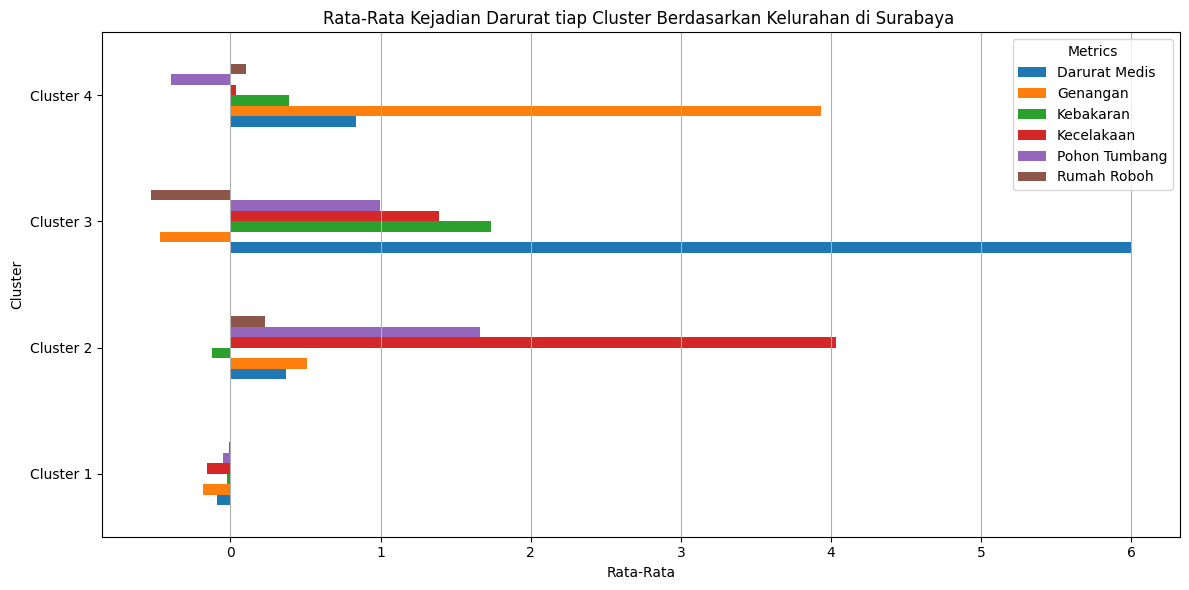

In [34]:
# Menghapus kolom korban
mean_df_without_victims = mean_df.drop(columns=['Korban Terdampak', 'Korban Luka', 'Korban Meninggal'])

# Mengatur ukuran plot
plt.figure(figsize=(12, 6))

# Membuat bar plot horizontal
mean_df_without_victims.set_index('Cluster').plot(kind='barh', figsize=(12, 6))

# Memberikan label pada sumbu
plt.title('Rata-Rata Kejadian Darurat tiap Cluster Berdasarkan Kelurahan di Surabaya ')
plt.xlabel('Rata-Rata')
plt.ylabel('Cluster')

# Menambahkan grid untuk membantu pembacaan
plt.grid(axis='x')

# Menyesuaikan orientasi label di sumbu y agar lebih jelas
plt.tight_layout()

# Menampilkan plot
plt.show()

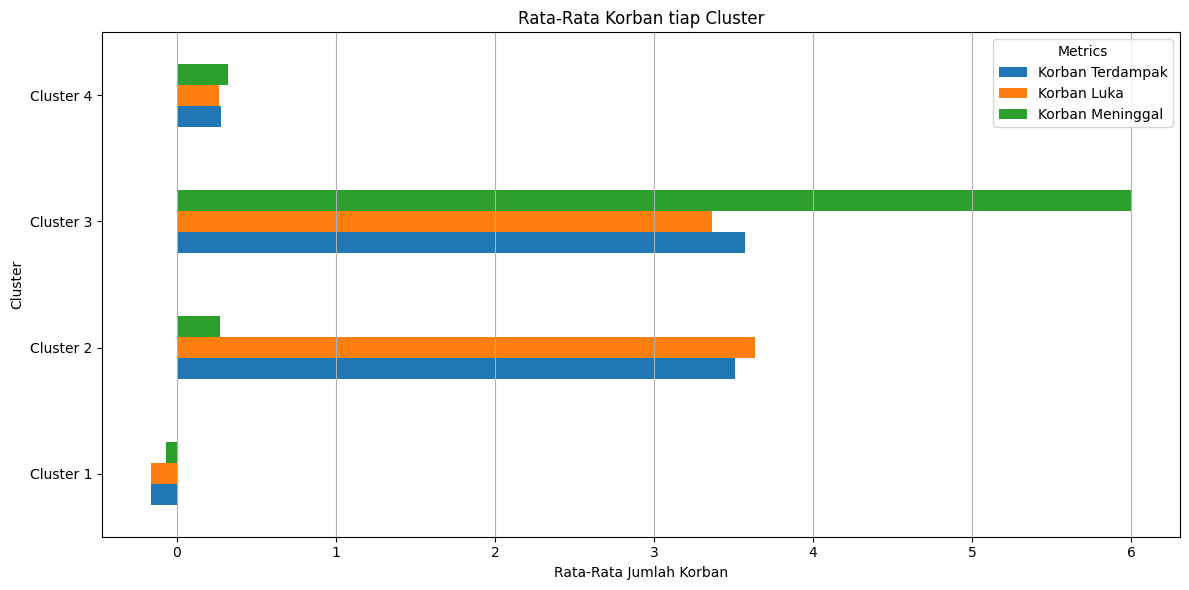

In [35]:
# Menghapus duplikat kolom
mean_df = mean_df.loc[:, ~mean_df.columns.duplicated()]

# Membuat bar plot horizontal untuk kolom yang berkaitan dengan korban
mean_df.set_index('Cluster')[['Korban Terdampak', 'Korban Luka', 'Korban Meninggal']].plot(kind='barh', figsize=(12, 6))

# Memberikan label pada sumbu
plt.title('Rata-Rata Korban tiap Cluster')
plt.xlabel('Rata-Rata Jumlah Korban')
plt.ylabel('Cluster')

# Menambahkan grid untuk membantu pembacaan
plt.grid(axis='x')

# Menyesuaikan orientasi label di sumbu y agar lebih jelas
plt.tight_layout()

# Menampilkan plot
plt.show()

In [36]:
print(mean_df.columns)


Index(['Cluster', 'Darurat Medis', 'Genangan', 'Kebakaran', 'Kecelakaan',
       'Pohon Tumbang', 'Rumah Roboh', 'Korban Terdampak', 'Korban Luka',
       'Korban Meninggal'],
      dtype='object', name='Metrics')


In [37]:
# Menghitung Davies-Bouldin Index
dbi = davies_bouldin_score(data_normalized, agglo.labels_)

# Menampilkan hasil evaluasi
print(f"Davies-Bouldin Index: {dbi:.4f}")


Davies-Bouldin Index: 0.8527
